In [2]:
#/work/notebooks/analyze_misranked_queries.ipynb

# selecting a query from specific rank buckets,
# printing the query and candidate (1st, golden) texts,
# and showing their features/terms so you can compare them

from pathlib import Path

def select_run(runs_root: str = "/work/runs", run_name: str | None = None) -> Path:
    """
    Select one run directory from /work/runs.
    
    Args:
        runs_root (str): Path to runs folder.
        run_name (str | None): If provided, must match an existing run folder.
                               If None, prints available runs and asks user to pick.
    
    Returns:
        Path to the selected run folder.
    """
    runs_root = Path(runs_root)
    if not runs_root.exists():
        raise FileNotFoundError(f"Runs root does not exist: {runs_root}")
    
    runs = sorted([p for p in runs_root.iterdir() if p.is_dir()])
    if not runs:
        raise RuntimeError(f"No runs found in {runs_root}")
    
    # Case 1: user specifies run name
    if run_name:
        match = [r for r in runs if r.name == run_name]
        if not match:
            raise ValueError(f"Run '{run_name}' not found. Available runs: {[r.name for r in runs]}")
        return match[0]
    
    # Case 2: interactive selection
    print("Available runs:")
    for i, r in enumerate(runs):
        print(f"[{i}] {r.name}")
    
    idx = int(input("Select a run by index: "))
    if idx < 0 or idx >= len(runs):
        raise IndexError(f"Invalid selection {idx}. Must be between 0 and {len(runs)-1}")
    
    return runs[idx]

run_dir = select_run("/work/runs")   # either pass run_name="tfidf_char_3_5" or pick interactively
print("Selected run:", run_dir)


Available runs:
[0] bm25_tiebreak__bm25_unigram__wN-1_0__wP-0_5
[1] bm25_unibigram
[2] bm25_unibigram__k1-0.80__b-0.35
[3] bm25_unibigram__k1-0.80__b-0.50
[4] bm25_unibigram__k1-0.80__b-0.65
[5] bm25_unibigram__k1-0.80__b-0.80
[6] bm25_unibigram__k1-0.80__b-0.95
[7] bm25_unibigram__k1-1.00__b-0.35
[8] bm25_unibigram__k1-1.00__b-0.50
[9] bm25_unibigram__k1-1.00__b-0.65
[10] bm25_unibigram__k1-1.00__b-0.80
[11] bm25_unibigram__k1-1.00__b-0.95
[12] bm25_unibigram__k1-1.20__b-0.35
[13] bm25_unibigram__k1-1.20__b-0.50
[14] bm25_unibigram__k1-1.20__b-0.65
[15] bm25_unibigram__k1-1.20__b-0.80
[16] bm25_unibigram__k1-1.20__b-0.95
[17] bm25_unibigram__k1-1.40__b-0.35
[18] bm25_unibigram__k1-1.40__b-0.50
[19] bm25_unibigram__k1-1.40__b-0.65
[20] bm25_unibigram__k1-1.40__b-0.80
[21] bm25_unibigram__k1-1.40__b-0.95
[22] bm25_unibigram__k1-1.60__b-0.35
[23] bm25_unibigram__k1-1.60__b-0.50
[24] bm25_unibigram__k1-1.60__b-0.65
[25] bm25_unibigram__k1-1.60__b-0.80
[26] bm25_unibigram__k1-1.60__b-0.95


Select a run by index:  54


Selected run: /work/runs/bm25_unigram_params


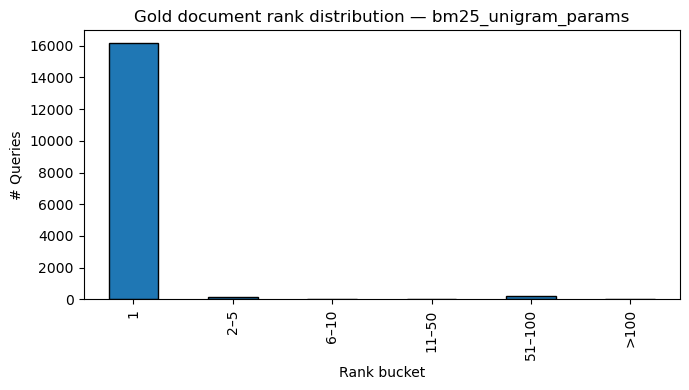

bucket
1         16153
2–5         186
6–10          0
11–50        56
51–100      195
>100          0
Name: count, dtype: int64


In [4]:
# Retrieval histogram

import pandas as pd
import matplotlib.pyplot as plt
from pathlib import Path

def plot_rank_histogram(run_dir: str, K: int = 100):
    """
    Build histogram of gold ranks vs queries, bucketed into:
    1, 2–5, 6–10, 11–50, 51–100, >100 (or not found).
    
    Args:
        run_dir (str): Path to a run folder inside /work/runs
        K (int): maximum rank considered in retrieval (default=100)
    """
    run_dir = Path(run_dir)
    summary_path = run_dir / "results_perquery_summary.csv"
    if not summary_path.exists():
        raise FileNotFoundError(f"Missing {summary_path}. Run metrics.ipynb first.")
    
    df = pd.read_csv(summary_path)
    if "rank_item" not in df.columns:
        raise KeyError("results_perquery_summary.csv must have 'rank_item' column")
    
    # Bucketize ranks
    def bucket(rank):
        if rank == 1: return "1"
        elif 2 <= rank <= 5: return "2–5"
        elif 6 <= rank <= 10: return "6–10"
        elif 11 <= rank <= 50: return "11–50"
        elif 51 <= rank <= K: return "51–100"
        else: return ">100"
    
    df["bucket"] = df["rank_item"].apply(bucket)
    hist = df["bucket"].value_counts().reindex(["1","2–5","6–10","11–50","51–100",">100"], fill_value=0)
    
    # Plot
    plt.figure(figsize=(7,4))
    hist.plot(kind="bar", edgecolor="black")
    plt.title(f"Gold document rank distribution — {run_dir.name}")
    plt.xlabel("Rank bucket")
    plt.ylabel("# Queries")
    plt.tight_layout()
    plt.show()
    
    return hist


# Example usage:
hist = plot_rank_histogram(run_dir)
print(hist)


In [8]:
import sys
import json, gzip, random
from pathlib import Path
import pandas as pd
from importlib import import_module
# Adjust path so Python can find /src/retrievers/*
SRC_DIR = Path("/work/src")   # change /work → your actual repo root
if str(SRC_DIR) not in sys.path:
    sys.path.insert(0, str(SRC_DIR))

# ------------------ helpers ------------------
def _discover_processed_from_results(results_path: Path):
    """Infer /work/data/processed, collection, index_path, and impl from the first record."""
    first = None
    with gzip.open(results_path, "rt", encoding="utf-8") as gz:
        for ln in gz:
            if ln.strip():
                first = json.loads(ln); break
    if first is None:
        raise RuntimeError(f"{results_path} is empty.")
    index_path = Path(first["meta"]["index_path"])
    idx_meta = json.loads((index_path / "meta.json").read_text(encoding="utf-8"))
    repo_root = index_path.parent.parent  # /work
    processed = repo_root / "data" / "processed"
    collection = idx_meta.get("collection", "OEB")
    impl = idx_meta.get("impl") or idx_meta.get("variant") or idx_meta.get("method")
    return processed, collection, index_path, impl

def _bucket(rank: float, K: int = 100) -> str:
    try:
        r = int(rank)
    except Exception:
        return ">100"
    if r == 1:         return "1"
    if 2 <= r <= 5:    return "2–5"
    if 6 <= r <= 10:   return "6–10"
    if 11 <= r <= 50:  return "11–50"
    if 51 <= r <= K:   return "51–100"
    return ">100"

def _invert_vocab(vocab_dict: dict):
    # sklearn-style vocab: term -> column
    return {col: term for term, col in vocab_dict.items()}

def _terms_from_text(vec, text: str):
    """
    Extract the concrete terms/ngrams produced by 'vec' for 'text'.
    Works for both TfidfVectorizer and CountVectorizer.
    """
    if text is None:
        text = ""
    Q = vec.transform([text]).tocsr()
    idx = Q.indices.tolist()
    vocab = getattr(vec, "vocabulary_", None)
    if vocab is None:
        return []
    inv = _invert_vocab(vocab)
    return [inv.get(j, f"col_{j}") for j in idx]

# ------------------ main ------------------
def sample_queries_all_buckets_terms(run_dir: str, K: int = 100, seed: int = 0):
    """
    For each bucket except '1', pick one random query (if available) and print:
      - query key_id, full text, *retriever* terms/ngrams
      - top-1 candidate key_id, full text, *retriever* terms/ngrams
      - gold candidate key_id, full text, *retriever* terms/ngrams
    """
    random.seed(seed)
    run_dir = Path(run_dir)
    if not run_dir.exists():
        raise FileNotFoundError(run_dir)

    summary_csv = run_dir / "results_perquery_summary.csv"
    exploded_csv = run_dir / "results_exploded_candidates.csv"
    if not summary_csv.exists() or not exploded_csv.exists():
        res_files = sorted(run_dir.glob("results_top*.jsonl.gz"))
        if not res_files:
            raise FileNotFoundError(f"No results_top*.jsonl.gz found in {run_dir}")
        raise FileNotFoundError(
            f"Missing {summary_csv.name} or {exploded_csv.name}. "
            f"Run metrics.ipynb for this run to generate them."
        )

    df_sum  = pd.read_csv(summary_csv)
    df_cand = pd.read_csv(exploded_csv)
    if "rank" in df_cand.columns:
        K = max(K, int(df_cand["rank"].max()))

    df_sum["bucket"] = df_sum["rank_item"].apply(lambda r: _bucket(r, K))
    desired_buckets = ["2–5","6–10","11–50","51–100",">100"]

    # Discover processed data + retriever module (impl) from results/meta
    res_path = sorted(run_dir.glob("results_top*.jsonl.gz"))[-1]
    processed_dir, collection, index_path, impl = _discover_processed_from_results(res_path)  # 

    # Load processed features
    short_path = processed_dir / f"{collection}_short_feats.parquet"
    long_path  = processed_dir / f"{collection}_long_feats.parquet"
    df_q = pd.read_parquet(short_path).rename(columns={"text_word":"q_text"})
    df_d = pd.read_parquet(long_path).rename(columns={"text_word":"d_text"})

    # Load the *exact* retriever used by this index; both BM25/TF–IDF expose a query vectorizer
    retr_mod = import_module(f"retrievers.{impl}")     # e.g., retrievers.bm25_unigram / retrievers.tfidf_unigram  
    searcher = retr_mod.load(index_path)               # returns Searcher with .vec_q                      
    vec = getattr(searcher, "vec_q", None)
    if vec is None:
        raise AttributeError(f"Retriever {impl} does not expose vec_q; cannot extract terms.")  # TF‑IDF retriever also exposes vec_q  

    q_text_map = df_q.set_index("item_key")["q_text"].astype(str).to_dict()
    d_text_map = df_d.set_index("item_key")["d_text"].astype(str).to_dict()

    for bucket in desired_buckets:
        pool = df_sum[df_sum["bucket"] == bucket]
        if pool.empty:
            print(f"\n--- Bucket {bucket}: no queries ---")
            continue

        # Pick a random query in this bucket
        qrow = pool.sample(1, random_state=random.randint(0, 10**9)).iloc[0]
        qkey = str(qrow["query_item_key"])

        # Candidate list for that query; take rank-1 candidate
        cands = df_cand[df_cand["query_item_key"].astype(str) == qkey]
        if cands.empty:
            print(f"\n--- Bucket {bucket}: chosen query has no candidates (unexpected) ---")
            continue
        top1 = cands.sort_values("rank").iloc[0]
        top1_key = str(top1["cand_item_key"])
        gold_key = qkey  # short→long alignment

        # Full texts
        q_text    = q_text_map.get(qkey, "")
        top1_text = d_text_map.get(top1_key, "(missing)")
        gold_text = d_text_map.get(gold_key, "(missing)")

        # Terms/ngrams from the *same* vectorizer on each text
        q_terms    = _terms_from_text(vec, q_text)
        top1_terms = _terms_from_text(vec, top1_text)
        gold_terms = _terms_from_text(vec, gold_text)

        print("\n" + "="*80)
        print(f"BUCKET: {bucket}")
        print("-"*80)
        print(f"Query key_id: {qkey}")
        print("Query text:")
        print(q_text)
        print("Query terms/ngrams (retriever):")
        print(q_terms)

        print("-"*80)
        print(f"1st candidate key_id: {top1_key}")
        print("1st candidate text:")
        print(top1_text)
        print("1st candidate terms/ngrams (retriever):")
        print(top1_terms)

        print("-"*80)
        print(f"Golden candidate key_id: {gold_key}")
        print("Golden candidate text:")
        print(gold_text)
        print("Golden candidate terms/ngrams (retriever):")
        print(gold_terms)

        # Optional: quick overlaps to help visual comparison
        try:
            s_q, s_top, s_gold = set(q_terms), set(top1_terms), set(gold_terms)
            inter_top  = sorted(s_q & s_top)
            inter_gold = sorted(s_q & s_gold)
            print("-"*80)
            print(f"Overlap(query ∩ top1): {len(inter_top)} terms")
            print(inter_top[:100])
            print(f"Overlap(query ∩ gold): {len(inter_gold)} terms")
            print(inter_gold[:100])
        except Exception:
            pass
sample_queries_all_buckets_terms(run_dir, seed=42)



BUCKET: 2–5
--------------------------------------------------------------------------------
Query key_id: OEB030hfcac
Query text:
canalización hormigonada 12 t polietileno libre de halógenos de 110 mm adosada diurno excepcional i 5 horas cualquier condición de ejecución
Query terms/ngrams (retriever):
['110', '12', '5', 'adosada', 'canalizacion', 'condicion', 'cualquier', 'de', 'diurno', 'ejecucion', 'excepcional', 'halogenos', 'horas', 'hormigonada', 'i', 'libre', 'mm', 'polietileno']
--------------------------------------------------------------------------------
1st candidate key_id: OEB020efcac
1st candidate text:
canalización hormigonada de 12 tubos de pvc de 110 mm de diámetro adosada o superficial incluso el relleno y el compactado de la zanja la preparación y nivelación de la solera suministro y montaje del encofrado elementos de fijación desencofrado el suministro y el montaje de los tubos y hormigón tipo he 20 sin vibrar la prueba de los conductos el transporte y la retirad